### **Queue** <br>
A queue Q is a data structure where elements are added at the back and removed at the front. <br>
Supported operations:
- Enqueue(x): add x to Q.<br>
- Dequeue(): remove and return the *first added* element in Q.<br>
- IsEmpty(): return True if Q is empty.<br><br>
All operations in O(1) time. Space is O(N). <br>
(This implementation uses a singly linked list)

In [52]:
class Node():
    def __init__(self, value):
        self.value = value
        self.next = None
        self.prev = None

class Queue():
    def __init__(self):
        self.size = 0
        self.front = None
        self.end = None
        self.queue = []
    
    def enqueue(self, x):
        node = Node(x)
        if self.end == None:
            self.front = node
            self.end = node
            self.size += 1
            self.queue.append(node.value)
            return
        
        # Inserting at the end of the queue
        if x >= self.end.value:
            node.prev = self.end
            self.end.next = node
            self.end = node
            self.queue.append(node.value)
            self.size += 1
        
        # Inserting an event with a timestamp that is less than the end of the queue
        current = self.front
        index = 0
        while current is not None:
            if x < current.value:
                node.next = current
                node.prev = current.prev

                if current.prev:
                    current.prev.next = node
                else:
                    self.front = node

                current.prev = node
                self.queue.insert(index, node.value)
                self.size += 1
                return

            current = current.next
            index += 1
        
        #print("Size of queue: ", self.size)
    
    def dequeue(self):
        if self.is_empty():
            raise Exception("Dequeueing from an empty queue")
        remove = self.front
        self.front = self.front.next
        self.size -= 1
        self.queue.remove(remove.value)
        if self.front == None:
            self.end = None
        else:
            self.front.prev = None 
        return remove.value

    def is_empty(self):
        return self.size == 0

In [2]:
queue2 = Queue()
queue2.enqueue(float('inf'))
print(queue2.queue)
queue2.enqueue(1.5)
print(queue2.queue)
print(queue2.front.value)
queue2.dequeue()
print(queue2.front.value)
queue2.enqueue(0.5)
print(queue2.queue)
print(queue2.front.value)

[inf]
[1.5, inf]
1.5
inf
[0.5, inf]
0.5


In [3]:
queue2.dequeue()
print(queue2.end.value)#.enqueue(0))
print(queue2.queue)
print(queue2.front.value)

inf
[inf]
inf


### **Defining the servers**

In [53]:
import random
#import simpy
import numpy
import random
import statistics
import heapq
#seed(42)

In [54]:
# lam = 2
# mu = 3
# simulation_time = 1000000

# Simulation executive
def random_number_generator(rate):
    return random.expovariate(rate) # waiting time between events of poisson distribution are exponentially distributed

In [55]:
def simulation_func(seed_value, simulation_time, lam, mu):

    # Initialization routine
    clock = 0.0
    arrival_queue = Queue()
    departure_queue = Queue()
    server_occupied = False
    all_arrival_times = []
    all_departure_times = []
    num_packages_in_system = 0
    num_in_queue = 0
    num_served = 0
    last_event_time = 0.0

    # Statistical counters
    area_num_in_queue = 0.0
    area_num_in_system = 0.0
    area_server_status = 0.0

    # Setting seed for reproducibility
    random.seed(seed_value)

    arrival_queue.enqueue(random_number_generator(lam)) # Schedule the first arrival at time 0
    departure_queue.enqueue(float('inf')) # No departure scheduled at the beginning

    while clock < simulation_time:
        last_event_time = clock

        if arrival_queue.front.value <= departure_queue.front.value:
            # Timing routine
            first_in_queue = arrival_queue.front.value
            clock = first_in_queue 

            # Statistical Counters Computation
            area_num_in_queue += num_in_queue * (clock - last_event_time)
            area_num_in_system += (num_in_queue + (1 if server_occupied else 0)) * (clock - last_event_time)
            area_server_status += (1 if server_occupied else 0) * (clock - last_event_time)

            # Pop the event from the arrival queue
            arrival_queue.dequeue()
        
            if server_occupied == False:
                server_occupied = True

                # Next departure
                next_departure_time = clock + random_number_generator(mu) 
                departure_queue.enqueue(next_departure_time)

            else:
                num_in_queue += 1
                #print("Number in queue: ", num_in_queue)

            # Next arrival
            next_arrival_time = clock + random_number_generator(lam) 
            arrival_queue.enqueue(next_arrival_time)
            all_arrival_times.append(clock)
            
        else:
            # Timing routine
            first_in_queue = departure_queue.front.value
            clock = first_in_queue 
            #print("Departure event time: ", clock)

            # Statistical Counters Computation
            area_num_in_queue += num_in_queue * (clock - last_event_time)
            area_num_in_system += (num_in_queue + (1 if server_occupied else 0)) * (clock - last_event_time)
            area_server_status += (1 if server_occupied else 0) * (clock - last_event_time)
            
            # Pop the event from the queue
            departure_queue.dequeue()
            num_served += 1
            all_departure_times.append(clock)
            
            if num_in_queue > 0:
                num_in_queue -= 1
                next_departure_time = clock + random_number_generator(mu)
                departure_queue.enqueue(next_departure_time)
                server_occupied = True
            else:
                server_occupied = False
                #departure_queue.enqueue(float("inf")) # Ensuring that departure queue is never empty
    
    return all_arrival_times, all_departure_times, area_num_in_queue, area_num_in_system, area_server_status, num_served

In [99]:
# Running several simulations
b = 10
seed_list = [random.randint(0, 1000000) for _ in range(b)]
lambda_value = 2
mu_value = 3
simulation_time_value = 50000

sample_means = []
sample_variances = []

arrival_time_pr_sim = []
departure_time_pr_sim = []

for seed_v in seed_list:
    arrival, departure, *_ = simulation_func(
        seed_value=seed_v,
        simulation_time=simulation_time_value,
        lam=lambda_value,
        mu=mu_value
    )

    diff = [d - a for d, a in zip(departure, arrival)]

    mean_diff = mean_diff = statistics.mean(diff)
    var_diff = statistics.variance(diff)

    sample_means.append(mean_diff)
    sample_variances.append(var_diff)

    arrival_time_pr_sim.append(arrival)
    departure_time_pr_sim.append(departure)

In [100]:
# For independent replications
Zb = 1/b * sum(sample_means)
print("Mean of sample means: ", Zb)

Vr_hat = 1/(b-1) * sum([(x - Zb)**2 for x in sample_means])
print("Estimated variance of the sample means: ", Vr_hat)

Mean of sample means:  1.0067952844789607
Estimated variance of the sample means:  0.0001441737900150285


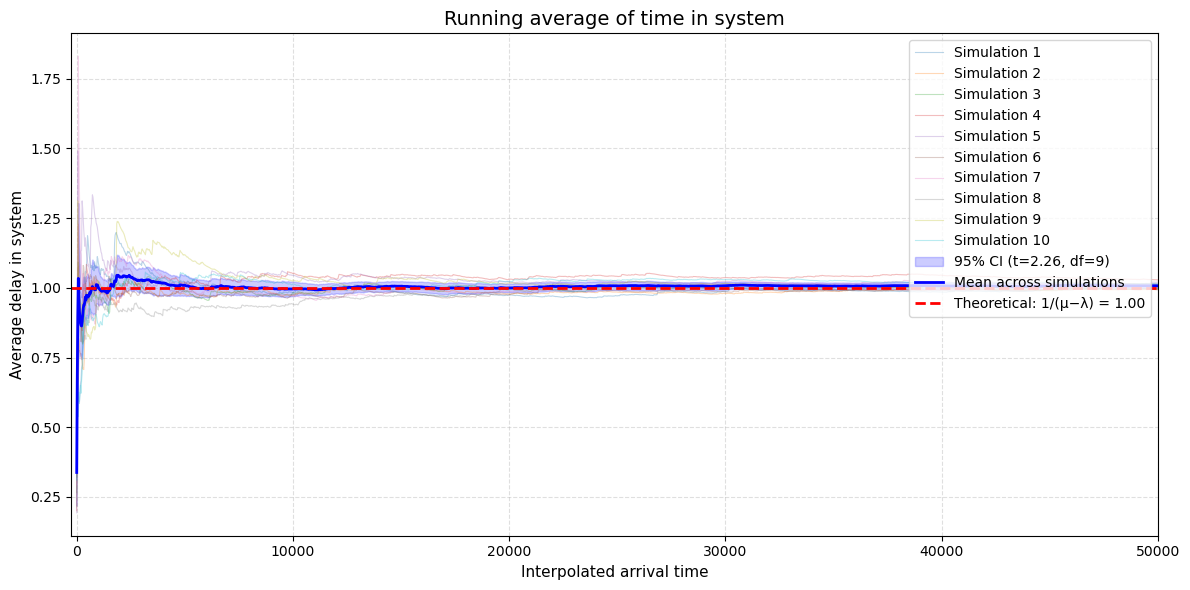

In [132]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

theoretical_average = 1 / (mu_value - lambda_value)

diff_pr_sim = [
    [d - a for d, a in zip(dep, arr)]
    for arr, dep in zip(arrival_time_pr_sim, departure_time_pr_sim)
]

def running_average(arr):
    return np.cumsum(arr) / np.arange(1, len(arr) + 1)

ra_sims = [running_average(np.array(sim)) for sim in diff_pr_sim]

# Common time grid from max start to min end across all simulations
t_start = max(arr[0] for arr in arrival_time_pr_sim)
t_end   = min(arr[-1] for arr in arrival_time_pr_sim)
common_grid = np.linspace(t_start, t_end, 2000)

# Interpolate each simulation onto the common time grid
interpolated = np.stack([
    np.interp(common_grid, arrival_time_pr_sim[i][:len(ra_sims[i])], ra_sims[i])
    for i in range(b)
], axis=0)

mean_curve = np.mean(interpolated, axis=0)
std_dev    = np.std(interpolated, axis=0, ddof=1)
t_crit     = stats.t.ppf(0.975, df=b-1)
ci_upper   = mean_curve + t_crit * std_dev / np.sqrt(b)
ci_lower   = mean_curve - t_crit * std_dev / np.sqrt(b)

fig, ax = plt.subplots(figsize=(12, 6))

# Individual simulations
for i in range(b):
    ax.plot(common_grid, interpolated[i], linewidth=0.8, alpha=0.3, label=f"Simulation {i+1}")

# CI and mean on the common grid
ax.fill_between(common_grid, ci_lower, ci_upper, color='blue', alpha=0.2, label=f"95% CI (t={t_crit:.2f}, df={b-1})")
ax.plot(common_grid, mean_curve, color='blue', linewidth=2, label="Mean across simulations")

ax.axhline(y=theoretical_average, linestyle='--', linewidth=2, color='red', label=f"Theoretical: 1/(µ−λ) = {theoretical_average:.2f}")

ax.set_title("Running average of time in system", fontsize=14)
ax.set_xlabel("Interpolated arrival time", fontsize=11)
ax.set_ylabel("Average delay in system", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right')
ax.set_xlim(-250, 50000)
plt.tight_layout()
plt.show()

### Changing $\lambda$ and $\mu$ values

In [134]:
# Changing mu and lamdba values
b = 5
seed_value = 42
lambda_list = [0.5, 1.0, 1.5, 2.0, 2.5]
mu_list = [1.0, 2.0, 3.0, 4.0, 5.0]
simulation_time_value = 50000

sample_means_2 = []
sample_variances_2 = []

arrival_time_pr_sim_2 = []
departure_time_pr_sim_2 = []

for lam, mu_value in zip(lambda_list, mu_list):
    arrival, departure, *_ = simulation_func(
        seed_value=seed_value,
        simulation_time=simulation_time_value,
        lam=lam,
        mu=mu_value
    )

    diff = [d - a for d, a in zip(departure, arrival)]

    mean_diff = mean_diff = statistics.mean(diff)
    var_diff = statistics.variance(diff)

    sample_means_2.append(mean_diff)
    sample_variances_2.append(var_diff)

    arrival_time_pr_sim_2.append(arrival)
    departure_time_pr_sim_2.append(departure)

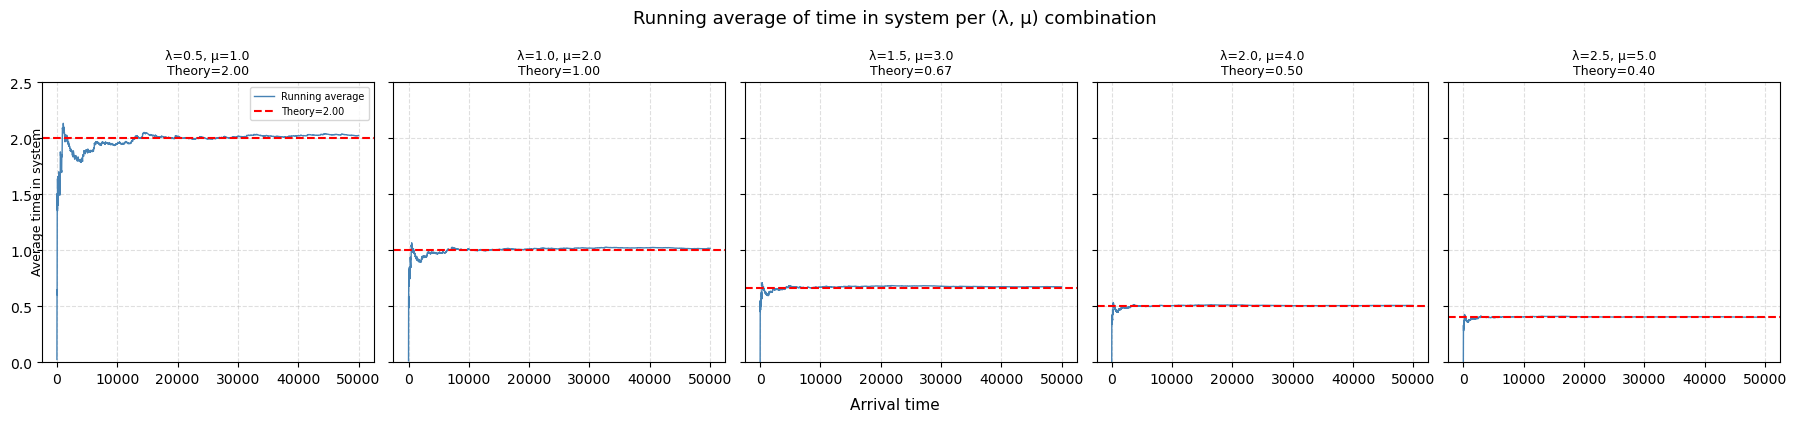

In [140]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

diff_pr_sim_2 = [[d - a for d, a in zip(dep, arr)] 
                 for arr, dep in zip(arrival_time_pr_sim_2, departure_time_pr_sim_2)]

def running_average(arr):
    return np.cumsum(arr) / np.arange(1, len(arr) + 1)

fig, axes = plt.subplots(1, len(lambda_list), figsize=(18, 4), sharey=True)

for idx, (lam, mu) in enumerate(zip(lambda_list, mu_list)):
    ax = axes[idx]
    theoretical = 1 / (mu - lam)

    # Only one simulation per (lam, mu) combo, so no CI — just plot directly
    ra = running_average(np.array(diff_pr_sim_2[idx]))
    arr_times = np.array(arrival_time_pr_sim_2[idx])

    n = min(len(arr_times), len(ra))
    ax.plot(arr_times[:n], ra[:n], linewidth=1, color='steelblue', label="Running average")
    ax.axhline(y=theoretical, linestyle='--', linewidth=1.5, color='red', label=f"Theory={theoretical:.2f}")
    ax.set_ylim(0, 2.5)
    ax.set_title(f"λ={lam}, μ={mu}\nTheory={theoretical:.2f}", fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

    if idx == 0:
        ax.legend(fontsize=7)

fig.text(0.5, -0.02, "Arrival time", ha='center', fontsize=11)
fig.text(0.02, 0.5, "Average time in system", va='center', rotation='vertical', fontsize=9)
plt.suptitle("Running average of time in system per (λ, μ) combination", fontsize=13)
plt.tight_layout()
plt.show()